In [1]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import (TOTAL_ROOMS,PRICE_LEVELS)

from src.environment import HotelPricingEnv

from src.q_learning import (choose_action,update_q_table)

from src.q_learning_utils import (state_to_index,initialize_q_table)

In [3]:
env = HotelPricingEnv()
q_table = initialize_q_table()

In [4]:
episodes = 1000
episode_rewards = []
for episode in range(episodes):
    state,_ = env.reset()
    done = False
    total_reward = 0
    while not done:
        state_index = state_to_index(state[0],state[1])
        action = choose_action(q_table,state_index)
        next_state,reward,done,_,info = env.step(action)
        next_index = state_to_index(next_state[0],next_state[1])
        update_q_table(q_table,state_index,action,reward,next_index)
        state = next_state
        total_reward += reward
    episode_rewards.append(total_reward)

In [5]:
print("Average Reward")
print(np.mean(episode_rewards))

Average Reward
3020.635


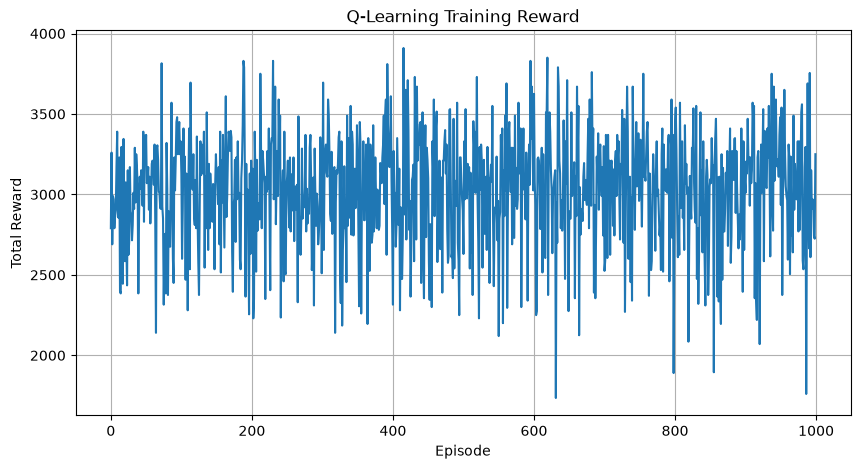

In [6]:
plt.figure(figsize=(10,5))

plt.plot(episode_rewards)

plt.title("Q-Learning Training Reward")

plt.xlabel("Episode")

plt.ylabel("Total Reward")

plt.grid(True)

plt.show()

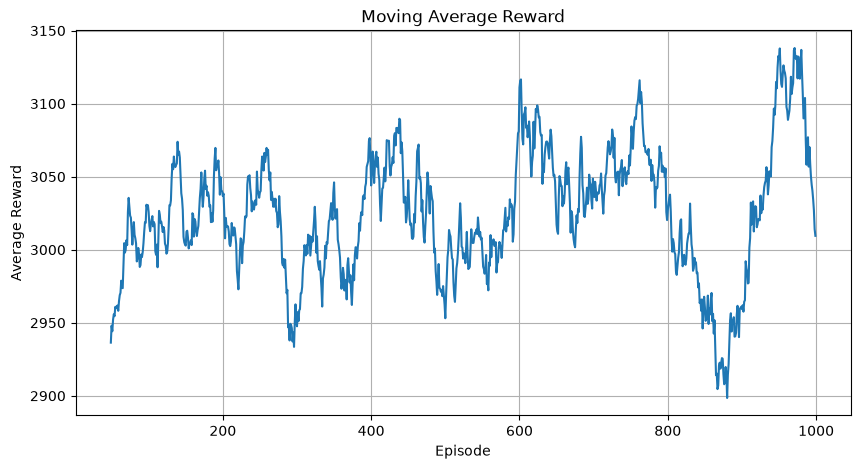

In [7]:
moving_average = pd.Series(episode_rewards).rolling(50).mean()

plt.figure(figsize=(10,5))

plt.plot(moving_average)

plt.title("Moving Average Reward")

plt.xlabel("Episode")

plt.ylabel("Average Reward")

plt.grid(True)

plt.show()

In [8]:
evaluation_episodes = 100
results = []

for episode in range(evaluation_episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0
    total_price = 0
    days = 0
    while not done:
        state_index = state_to_index(state[0],state[1])
        action = np.argmax(q_table[state_index])
        price = PRICE_LEVELS[action]
        total_price += price
        next_state, reward, done, _, info = env.step(action)
        total_reward += reward
        state = next_state
        days += 1
    rooms_sold = TOTAL_ROOMS - state[0]
    occupancy = (rooms_sold / TOTAL_ROOMS) * 100
    average_price = total_price / days

    results.append({
        "Revenue": total_reward,
        "Rooms Sold": rooms_sold,
        "Occupancy": occupancy,
        "Average Price": average_price
    })

results = pd.DataFrame(results)

results.head()

,Revenue,Rooms Sold,Occupancy,Average Price
0,2095,37,74.0,96.000000
1,2830,46,92.0,92.000000
2,3115,49,98.0,96.666667
3,3110,50,100.0,95.384615
4,3110,50,100.0,90.666667


In [9]:
baseline = pd.read_csv(r"E:\AARAV\Infotact-DS-ML\Project-2-Dynamic-Pricing\data\processed\baseline_results.csv")
qlearning = pd.DataFrame({
    "Strategy":["Q-Learning"],
    "Average Revenue":[results["Revenue"].mean()],
    "Average Rooms Sold":[results["Rooms Sold"].mean()],
    "Average Occupancy (%)":[results["Occupancy"].mean()],
    "Average Price":[results["Average Price"].mean()],
    "Episodes":[evaluation_episodes]
})
comparison = pd.concat([baseline,qlearning],ignore_index=True)
comparison

,Strategy,Average Revenue,Average Rooms Sold,Average Occupancy (%),Average Price,Episodes
0,Fixed,3638.50,38.30,76.60,120.000000,50
1,Random,3202.10,37.74,75.48,119.493333,50
2,Discount,3051.50,36.58,73.16,126.666667,50
3,Q-Learning,2908.25,46.63,93.26,92.413690,100


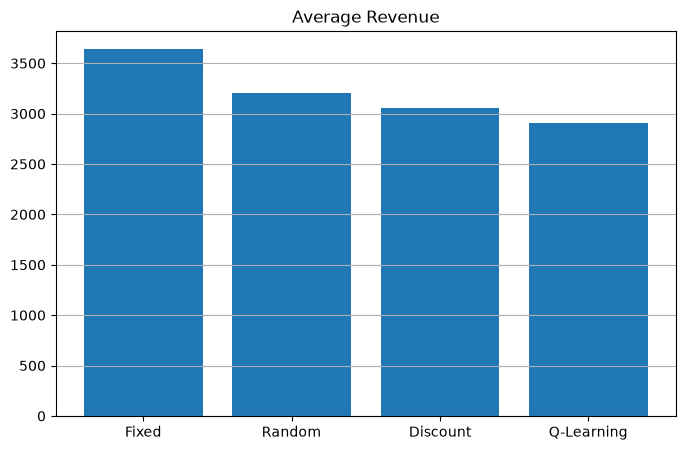

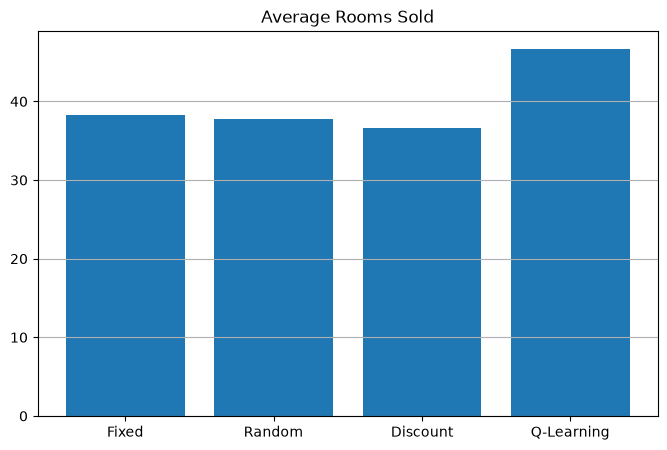

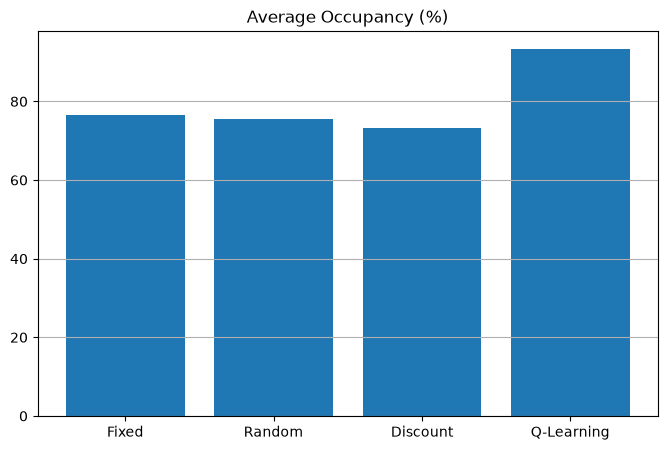

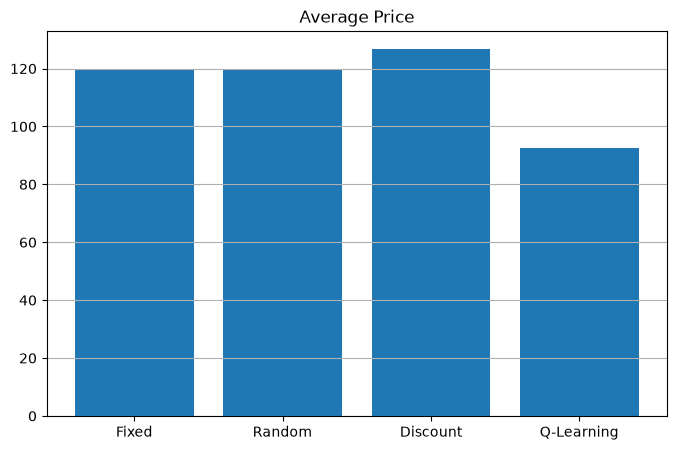

In [10]:
metrics = [
    "Average Revenue",
    "Average Rooms Sold",
    "Average Occupancy (%)",
    "Average Price"
]

for metric in metrics:
    plt.figure(figsize=(8,5))

    plt.bar(comparison["Strategy"],comparison[metric])

    plt.title(metric)

    plt.grid(axis="y")

    plt.show()

In [11]:
comparison.to_csv(r"E:\AARAV\Infotact-DS-ML\Project-2-Dynamic-Pricing\data\processed\qlearning_results.csv",index=False)
np.save(r"..\models\q_table.npy",q_table)
print("Results Saved Successfully.")

Results Saved Successfully.
